# 00 — Data Setup & EDA: Sri Lanka Dengue

This notebook is step 1 of 3 in the baseline-reproduction pipeline for
**"Physics-Informed, GAN-Augmented Graph Neural Networks for Dengue Incidence Forecasting."**

It targets the same dataset as **Weng et al. (2024), "Graph Representation Learning for
Dengue Forecasting"** (NASA/IEEE BigData 2024) — Sri Lanka's 25 districts, weekly dengue
case counts. Reference implementation:
[`MLOpenSourceOpenScience/disease_modeling_MLOS2`](https://github.com/MLOpenSourceOpenScience/disease_modeling_MLOS2)

**This notebook auto-detects which stage your data is at and adapts:**

- **Processed mode** — if `MLSO2_Final.csv` (with NASA meteorological covariates
  already joined) + a `*shifted*.npy` graph tensor + `sri_lanka_adj_list.json` are
  found, it uses those directly, exactly matching the reference repo.
- **Raw mode** — if only a raw NLP-extracted disease-case export is found (columns like
  `Disease Name, Cases, Location Name, TimeStampStart`, no weather covariates), it
  **cleans and builds a disease-case-only dataset from it**: normalizes messy district
  names, drops non-district aggregate rows, pivots into a weekly (district × week)
  matrix, and constructs the `(T, N=25, 1)` tensor the GNN models need. The district
  adjacency graph is fetched directly from the reference repo (Sri Lanka's district
  geography doesn't change, so it's safe to reuse regardless of which mode you're in).

Either way, it ends by writing `data_manifest.json` for notebooks 01/02 to read.

## 1. Environment detection & installs

In [1]:
import sys, os, json, subprocess

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ
print(f"Colab: {IN_COLAB} | Kaggle: {IN_KAGGLE}")

REQS = ["pandas", "numpy", "matplotlib", "seaborn", "gdown", "requests"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *REQS])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

Colab: True | Kaggle: False


## 2. Chart style (shared across all 3 notebooks)

A fixed categorical palette (colorblind-checked) so "ARIMA" or "STGAT" always gets the
same color everywhere, gridlines stay recessive, and we never fall back to matplotlib's
default rainbow cycle.

In [2]:
COLORS = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CAT_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE, BASELINE = "#e1e0d9", "#fcfcfb", "#c3c2b7"
DIVERGING = ["#2a78d6", "#f0efec", "#e34948"]  # blue -> gray -> red (for correlation, a signed quantity)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": GRID, "axes.grid": True, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})

def style_ax(ax):
    ax.grid(axis="y", linewidth=0.8, color=GRID)
    ax.set_axisbelow(True)
    return ax

## 3. Locate the dataset

Your team's Drive folder: `https://drive.google.com/drive/folders/1ZwYnRBuaZVCiMKLNA7ADw7AZMRk5wpee`
("Dengue Forecasting GNN"). Make sure you've added a shortcut to it under your own
**My Drive** first (folder dropdown → *Organize → Add shortcut*) — Colab can only mount
your own Drive.

In [3]:
DRIVE_FOLDER_ID = "1ZwYnRBuaZVCiMKLNA7ADw7AZMRk5wpee"

# Edit this if your shortcut has a different name once it's under MyDrive.
DRIVE_SHORTCUT_CANDIDATES = [
    "MyDrive/Dengue Forecasting GNN",
    "MyDrive/disease_modeling_MLOS2",
    "MyDrive/DNN_Dengue",
]

CANDIDATE_ROOTS = []

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    for c in DRIVE_SHORTCUT_CANDIDATES:
        CANDIDATE_ROOTS.append(os.path.join("/content/drive", c))
    CANDIDATE_ROOTS.append("/content/drive/MyDrive")  # last resort: search whole Drive

CANDIDATE_ROOTS += ["./Data", "/content/Data", "/kaggle/input", "."]
print("Search roots:", CANDIDATE_ROOTS)

Mounted at /content/drive
Search roots: ['/content/drive/MyDrive/Dengue Forecasting GNN', '/content/drive/MyDrive/disease_modeling_MLOS2', '/content/drive/MyDrive/DNN_Dengue', '/content/drive/MyDrive', './Data', '/content/Data', '/kaggle/input', '.']


In [4]:
def find_file(root, name_substr, ext):
    if not os.path.isdir(root):
        return None
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith(ext) and name_substr.lower() in fn.lower():
                return os.path.join(dirpath, fn)
    return None

def find_all_files(root, ext):
    out = []
    if not os.path.isdir(root):
        return out
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower().endswith(ext):
                out.append(os.path.join(dirpath, fn))
    return out

# Look for a fully-processed export first (matches the reference repo exactly).
found = {"csv": None, "npy": None, "adj": None}
for root in CANDIDATE_ROOTS:
    if all(found.values()):
        break
    if found["csv"] is None:
        found["csv"] = find_file(root, "MLSO2", ".csv") or find_file(root, "Final", ".csv")
    if found["npy"] is None:
        found["npy"] = find_file(root, "shifted", ".npy")
    if found["adj"] is None:
        found["adj"] = find_file(root, "adj", ".json")

print("Processed-format files found:")
for k, v in found.items():
    print(f"  {k}: {v}")

Processed-format files found:
  csv: None
  npy: None
  adj: /content/drive/MyDrive/Dengue Forecasting GNN/reference_repo/Models/sri_lanka_adj_list.json


In [5]:
# If the processed export isn't there, look for a raw NLP-extracted disease-case CSV
# instead (columns like Disease Name / Cases / Location Name / TimeStampStart) and
# sniff its header to confirm, rather than relying on a specific filename.
RAW_NLP_COLUMNS = {"Cases", "Location Name", "TimeStampStart"}
raw_csv_path = None

if not all(found.values()):
    print("Processed export incomplete — scanning for a raw NLP-extracted CSV instead...")
    candidates = []
    for root in CANDIDATE_ROOTS:
        candidates += find_all_files(root, ".csv")
    for path in candidates:
        try:
            cols = set(pd.read_csv(path, nrows=1).columns)
        except Exception:
            continue
        if RAW_NLP_COLUMNS.issubset(cols):
            raw_csv_path = path
            break

MODE = "processed" if all(found.values()) else ("raw" if raw_csv_path else None)
print(f"\nMODE = {MODE!r}")
if MODE == "raw":
    print(f"Raw NLP-extracted file: {raw_csv_path}")
elif MODE is None:
    raise FileNotFoundError(
        "Found neither a processed export (MLSO2_Final.csv + *shifted*.npy + adj list) "
        "nor a raw NLP-extracted CSV (needs columns Cases/Location Name/TimeStampStart) "
        "anywhere under: " + ", ".join(CANDIDATE_ROOTS) + ". "
        "Double-check the Drive shortcut, or set paths manually below."
    )

Processed export incomplete — scanning for a raw NLP-extracted CSV instead...

MODE = 'raw'
Raw NLP-extracted file: /content/drive/MyDrive/Dengue Forecasting GNN/datasets/output_Dengue Fever.csv


## 4. Raw mode: clean the NLP-extracted export

Only runs if `MODE == "raw"`. The raw export has real data-quality issues typical of
NLP/OCR-extracted tables — handled here with a **transparent, mechanical rule** wherever
possible, and a couple of **explicit config choices** you can change below rather than
silent guesses.

**What gets fixed:**
- Truncated names (`Anuradhapur`, `Hambantot`, `Trincomale`, ...) → resolved by prefix
  match against the 25 canonical district names (`"Anuradhapura".startswith("Anuradhapur")`).
- Spelling variants (`Monaragala` vs. the graph's `Moneragala`) → explicit alias.
- National-aggregate rows (`SRILANKA`, `94SRILANKA`) and unidentifiable fragments
  (`paha`) → dropped (summing them into a district total would double-count).
- `Kalmunai` / `Kalmune` / `Kalmunei` — a town inside Ampara District, not one of the 25
  districts itself. Default: folded into Ampara. **Check `KALMUNAI_HANDLING` below and
  change it if your team knows this double-counts** (i.e. if Ampara's own rows already
  include Kalmunai).

**What this does NOT fix:** your raw export covers **2017-04-01 to 2020-10-31** (~3.5
years) vs. Weng et al.'s 2013–2022 (9 years) — confirm with your team whether a fuller
export exists before treating this as final.

In [6]:
# --- Config knobs — change these if your team's judgment differs ---
KALMUNAI_HANDLING = "fold_into_ampara"   # alternatives: "drop", "separate_node"
MIN_WEEKS_TO_KEEP_DISTRICT = 10          # drop districts with fewer reported weeks than this
# ---------------------------------------------------------------------

if MODE == "raw":
    import requests

    ADJ_URL = "https://raw.githubusercontent.com/MLOpenSourceOpenScience/disease_modeling_MLOS2/main/Models/sri_lanka_adj_list.json"
    os.makedirs("./Data/processed", exist_ok=True)
    adj_local_path = "./Data/processed/sri_lanka_adj_list.json"
    r = requests.get(ADJ_URL, timeout=30)
    r.raise_for_status()
    with open(adj_local_path, "w") as f:
        f.write(r.text)
    adj_reference = json.load(open(adj_local_path))
    CANONICAL_DISTRICTS = sorted(adj_reference.keys())
    print(f"Fetched adjacency graph: {len(CANONICAL_DISTRICTS)} canonical districts.")
    print(CANONICAL_DISTRICTS)

Fetched adjacency graph: 25 canonical districts.
['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Moneragala', 'Mullaitivu', 'NuwaraEliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']


In [7]:
if MODE == "raw":
    MANUAL_ALIASES = {
        "Monaragala": "Moneragala",
        "Kalmunai": "Ampara" if KALMUNAI_HANDLING == "fold_into_ampara" else None,
        "Kalmune": "Ampara" if KALMUNAI_HANDLING == "fold_into_ampara" else None,
        "Kalmunei": "Ampara" if KALMUNAI_HANDLING == "fold_into_ampara" else None,
    }
    DROP_EXPLICIT = {"94SRILANKA", "SRILANKA", "paha"}

    def normalize_district(raw_name):
        name = str(raw_name).strip()
        if name in DROP_EXPLICIT:
            return None
        if name in CANONICAL_DISTRICTS:
            return name
        if name in MANUAL_ALIASES:
            return MANUAL_ALIASES[name]  # may be None (explicit drop, e.g. Kalmunai if "drop")
        # Prefix match: raw fragment is a truncation of exactly one canonical name.
        prefix_matches = [c for c in CANONICAL_DISTRICTS if c.startswith(name)]
        if len(prefix_matches) == 1:
            return prefix_matches[0]
        return None  # unresolved -> dropped, reported below

    raw_df = pd.read_csv(raw_csv_path)
    raw_df["_canonical"] = raw_df["Location Name"].apply(normalize_district)

    resolved = raw_df[raw_df["_canonical"].notna()]
    dropped = raw_df[raw_df["_canonical"].isna()]

    print("Name resolution:")
    mapping_seen = resolved[["Location Name", "_canonical"]].drop_duplicates().sort_values("_canonical")
    for _, row in mapping_seen.iterrows():
        print(f"  {row['Location Name']!r:20s} -> {row['_canonical']}")
    print(f"\nDropped {len(dropped)} rows ({dropped['Location Name'].nunique()} distinct raw names): "
          f"{sorted(dropped['Location Name'].unique())}")
    print(f"Kept {len(resolved)} of {len(raw_df)} rows.")

Name resolution:
  'Kalmunai'           -> Ampara
  'Kalmunei'           -> Ampara
  'Kalmune'            -> Ampara
  'Ampara'             -> Ampara
  'Anuradhap'          -> Anuradhapura
  'Anuradhapu'         -> Anuradhapura
  'Anuradhapur'        -> Anuradhapura
  'Anuradhapura'       -> Anuradhapura
  'Badulla'            -> Badulla
  'Batticaloa'         -> Batticaloa
  'Colombo'            -> Colombo
  'Galle'              -> Galle
  'Gampaha'            -> Gampaha
  'Hambantot'          -> Hambantota
  'Hambantota'         -> Hambantota
  'Jaffna'             -> Jaffna
  'Kalutara'           -> Kalutara
  'Kandy'              -> Kandy
  'Kegalle'            -> Kegalle
  'Kilinochchi'        -> Kilinochchi
  'Kurunegala'         -> Kurunegala
  'Mannar'             -> Mannar
  'Matale'             -> Matale
  'Matara'             -> Matara
  'Monaragala'         -> Moneragala
  'Mullaitivu'         -> Mullaitivu
  'NuwaraEliya'        -> NuwaraEliya
  'Nuwara'             -> Nuwa

In [8]:
if MODE == "raw":
    resolved = resolved.copy()
    resolved["Week"] = pd.to_datetime(resolved["TimeStampStart"])

    # Multiple raw rows can map to the same (district, week) — e.g. duplicate source
    # files, or an OCR-truncated name and its full form both appearing. Sum them; if
    # that's wrong for your data (rather than a genuine duplicate report), the dup
    # count printed below tells you how much this affects the total.
    dup_groups = resolved.groupby(["_canonical", "Week"]).size()
    n_dups = int((dup_groups > 1).sum())
    print(f"(district, week) groups with >1 raw row (summed together): {n_dups} of {len(dup_groups)}")

    long_df = (
        resolved.groupby(["_canonical", "Week"], as_index=False)["Cases"].sum()
        .rename(columns={"_canonical": "region", "Cases": "cases"})
    )

    # Drop districts with too little coverage to be useful, report what's left.
    weeks_per_district = long_df.groupby("region")["Week"].nunique().sort_values()
    print("\nWeeks of data per district:")
    print(weeks_per_district)
    keep_districts = weeks_per_district[weeks_per_district >= MIN_WEEKS_TO_KEEP_DISTRICT].index.tolist()
    dropped_districts = sorted(set(weeks_per_district.index) - set(keep_districts))
    if dropped_districts:
        print(f"\nDropping districts below {MIN_WEEKS_TO_KEEP_DISTRICT} weeks of coverage: {dropped_districts}")
    long_df = long_df[long_df["region"].isin(keep_districts)]

    # Reindex every kept district against the full union of reported weeks — missing
    # (district, week) combinations become explicit zeros, tracked via `_observed` so
    # you can distinguish "reported zero cases" from "no report that week" later.
    all_weeks = sorted(long_df["Week"].unique())
    all_districts = sorted(long_df["region"].unique())
    full_index = pd.MultiIndex.from_product([all_districts, all_weeks], names=["region", "Week"])
    long_df = (
        long_df.set_index(["region", "Week"]).reindex(full_index)
        .reset_index()
    )
    long_df["_observed"] = long_df["cases"].notna()
    long_df["cases"] = long_df["cases"].fillna(0.0)

    pct_imputed = 100 * (~long_df["_observed"]).mean()
    print(f"\n{len(all_districts)} districts x {len(all_weeks)} weeks "
          f"({all_weeks[0].date()} to {all_weeks[-1].date()})")
    print(f"{pct_imputed:.1f}% of (district, week) cells were not reported and filled with 0.")

(district, week) groups with >1 raw row (summed together): 599 of 13745

Weeks of data per district:
region
Gampaha         521
Ampara          551
Badulla         551
Anuradhapura    551
Batticaloa      551
Colombo         551
Galle           551
Hambantota      551
Jaffna          551
Kalutara        551
Kandy           551
Kegalle         551
Kilinochchi     551
Kurunegala      551
Mannar          551
Matale          551
Matara          551
Moneragala      551
Mullaitivu      551
NuwaraEliya     551
Polonnaruwa     551
Puttalam        551
Ratnapura       551
Trincomalee     551
Vavuniya        551
Name: Week, dtype: int64

25 districts x 551 weeks (2013-05-15 to 2024-02-24)
0.2% of (district, week) cells were not reported and filled with 0.


In [9]:
if MODE == "raw":
    clean_csv_path = "./Data/processed/sri_lanka_disease_only.csv"
    long_df[["Week", "region", "cases"]].to_csv(clean_csv_path, index=False)

    # Build the (T, N, 1) tensor for the GNN notebook, district order matching the
    # adjacency graph's sorted keys (only the districts we actually kept).
    node_districts = [d for d in CANONICAL_DISTRICTS if d in all_districts]
    pivot = long_df.pivot(index="Week", columns="region", values="cases").reindex(
        index=all_weeks, columns=node_districts
    )
    tensor = pivot.to_numpy(dtype=float)[:, :, None]  # (T, N, 1)
    npy_out_path = "./Data/processed/sri_lanka_disease_only.npy"
    np.save(npy_out_path, tensor)

    CSV_PATH, NPY_PATH, ADJ_PATH = clean_csv_path, npy_out_path, adj_local_path
    N_FEATURES = 1
    DISEASE_FEATURE_INDEX = 0
    print(f"Wrote {clean_csv_path}  (long format: Week, region, cases)")
    print(f"Wrote {npy_out_path}  shape={tensor.shape}")
    print(f"Adjacency: {adj_local_path} (trimmed to the {len(node_districts)} kept districts implicitly "
          f"— {[d for d in CANONICAL_DISTRICTS if d not in node_districts]} have no graph neighbors data-side)")

Wrote ./Data/processed/sri_lanka_disease_only.csv  (long format: Week, region, cases)
Wrote ./Data/processed/sri_lanka_disease_only.npy  shape=(551, 25, 1)
Adjacency: ./Data/processed/sri_lanka_adj_list.json (trimmed to the 25 kept districts implicitly — [] have no graph neighbors data-side)


In [10]:
if MODE == "processed":
    # Manual override — uncomment and edit if auto-discovery didn't find everything.
    # found["csv"] = "/content/drive/MyDrive/.../MLSO2_Final.csv"
    # found["npy"] = "/content/drive/MyDrive/.../sri_lanka_2013-2022_shifted.npy"
    # found["adj"] = "/content/drive/MyDrive/.../sri_lanka_adj_list.json"
    CSV_PATH, NPY_PATH, ADJ_PATH = found["csv"], found["npy"], found["adj"]
    N_FEATURES = None  # determined from the tensor itself below
    DISEASE_FEATURE_INDEX = None  # = shape[-1] - 6, set below

print(f"\nCSV_PATH = {CSV_PATH}\nNPY_PATH = {NPY_PATH}\nADJ_PATH = {ADJ_PATH}")


CSV_PATH = ./Data/processed/sri_lanka_disease_only.csv
NPY_PATH = ./Data/processed/sri_lanka_disease_only.npy
ADJ_PATH = ./Data/processed/sri_lanka_adj_list.json


## 5. Load & sanity-check the data

In [11]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(13775, 3)


,Week,region,cases
0,2013-05-15,Ampara,4.0
1,2013-06-22,Ampara,2.0
2,2013-06-29,Ampara,5.0
3,2013-07-13,Ampara,4.0
4,2013-07-20,Ampara,6.0


In [12]:
districts = sorted(df["region"].unique())
print(f"{len(districts)} districts:", districts)
if MODE == "processed":
    assert len(districts) == 25, "Expected Weng et al.'s 25 Sri Lanka districts — check the CSV."

print("\nColumns:", list(df.columns))
print("\nRows per district:")
print(df["region"].value_counts().describe())

25 districts: ['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Moneragala', 'Mullaitivu', 'NuwaraEliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']

Columns: ['Week', 'region', 'cases']

Rows per district:
count     25.0
mean     551.0
std        0.0
min      551.0
25%      551.0
50%      551.0
75%      551.0
max      551.0
Name: count, dtype: float64


In [13]:
x = np.load(NPY_PATH, allow_pickle=True)
x = np.nan_to_num(x.astype(float))
print("Graph tensor shape (T, N, F):", x.shape)
assert x.shape[1] == len(districts), "Tensor's district axis should match the CSV's district count."

adj = json.load(open(ADJ_PATH))
print(f"Adjacency: {len(adj)} nodes total; districts present in data: {len(districts)}")

if MODE == "processed":
    DISEASE_FEATURE_INDEX = x.shape[-1] - 6  # matches evaluation.py's `x[..., -6]` convention
    N_FEATURES = x.shape[-1]
print(f"N_FEATURES={N_FEATURES}, DISEASE_FEATURE_INDEX={DISEASE_FEATURE_INDEX}")

Graph tensor shape (T, N, F): (551, 25, 1)
Adjacency: 25 nodes total; districts present in data: 25
N_FEATURES=1, DISEASE_FEATURE_INDEX=0


In [14]:
disease_col_idx = DISEASE_FEATURE_INDEX
node_order = {i: v for i, v in enumerate(sorted(adj.keys())) if v in districts}
npy_total_cases = x[:, :, disease_col_idx].sum()
csv_total_cases = df["cases"].sum()
print(f"npy disease-column sum: {npy_total_cases:,.0f}")
print(f"csv 'cases' column sum:  {csv_total_cases:,.0f}")
print("(These should match closely in raw mode since both derive from the same cleaned "
      "long_df; in processed mode they may differ slightly if the npy is normalized.)")

npy disease-column sum: 605,893
csv 'cases' column sum:  605,893
(These should match closely in raw mode since both derive from the same cleaned long_df; in processed mode they may differ slightly if the npy is normalized.)


## 6. EDA

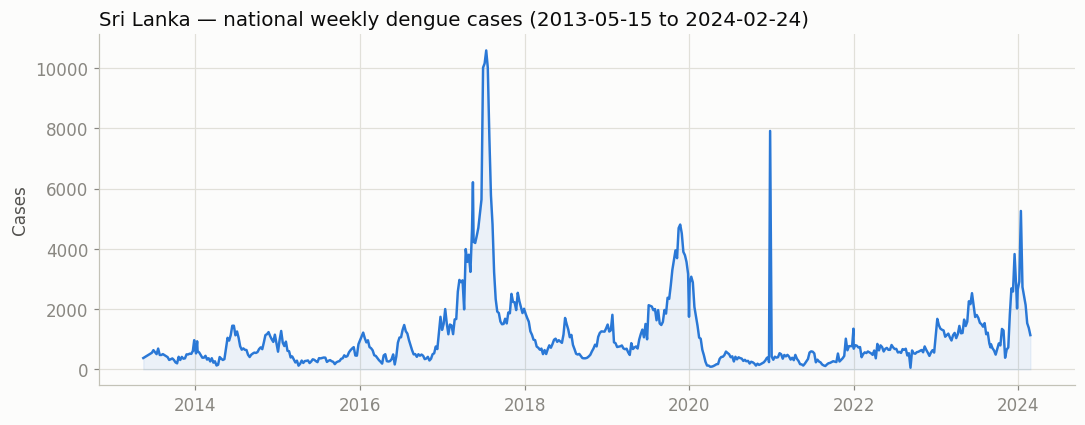

In [15]:
df["Week"] = pd.to_datetime(df["Week"])
national = df.groupby("Week", as_index=False)["cases"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(national["Week"], national["cases"], color=COLORS["blue"], linewidth=1.6)
ax.fill_between(national["Week"], national["cases"], color=COLORS["blue"], alpha=0.08)
style_ax(ax)
date_range = f"{national['Week'].min().date()} to {national['Week'].max().date()}"
ax.set_title(f"Sri Lanka — national weekly dengue cases ({date_range})", color=INK, fontsize=13, loc="left")
ax.set_ylabel("Cases")
plt.tight_layout()
plt.show()

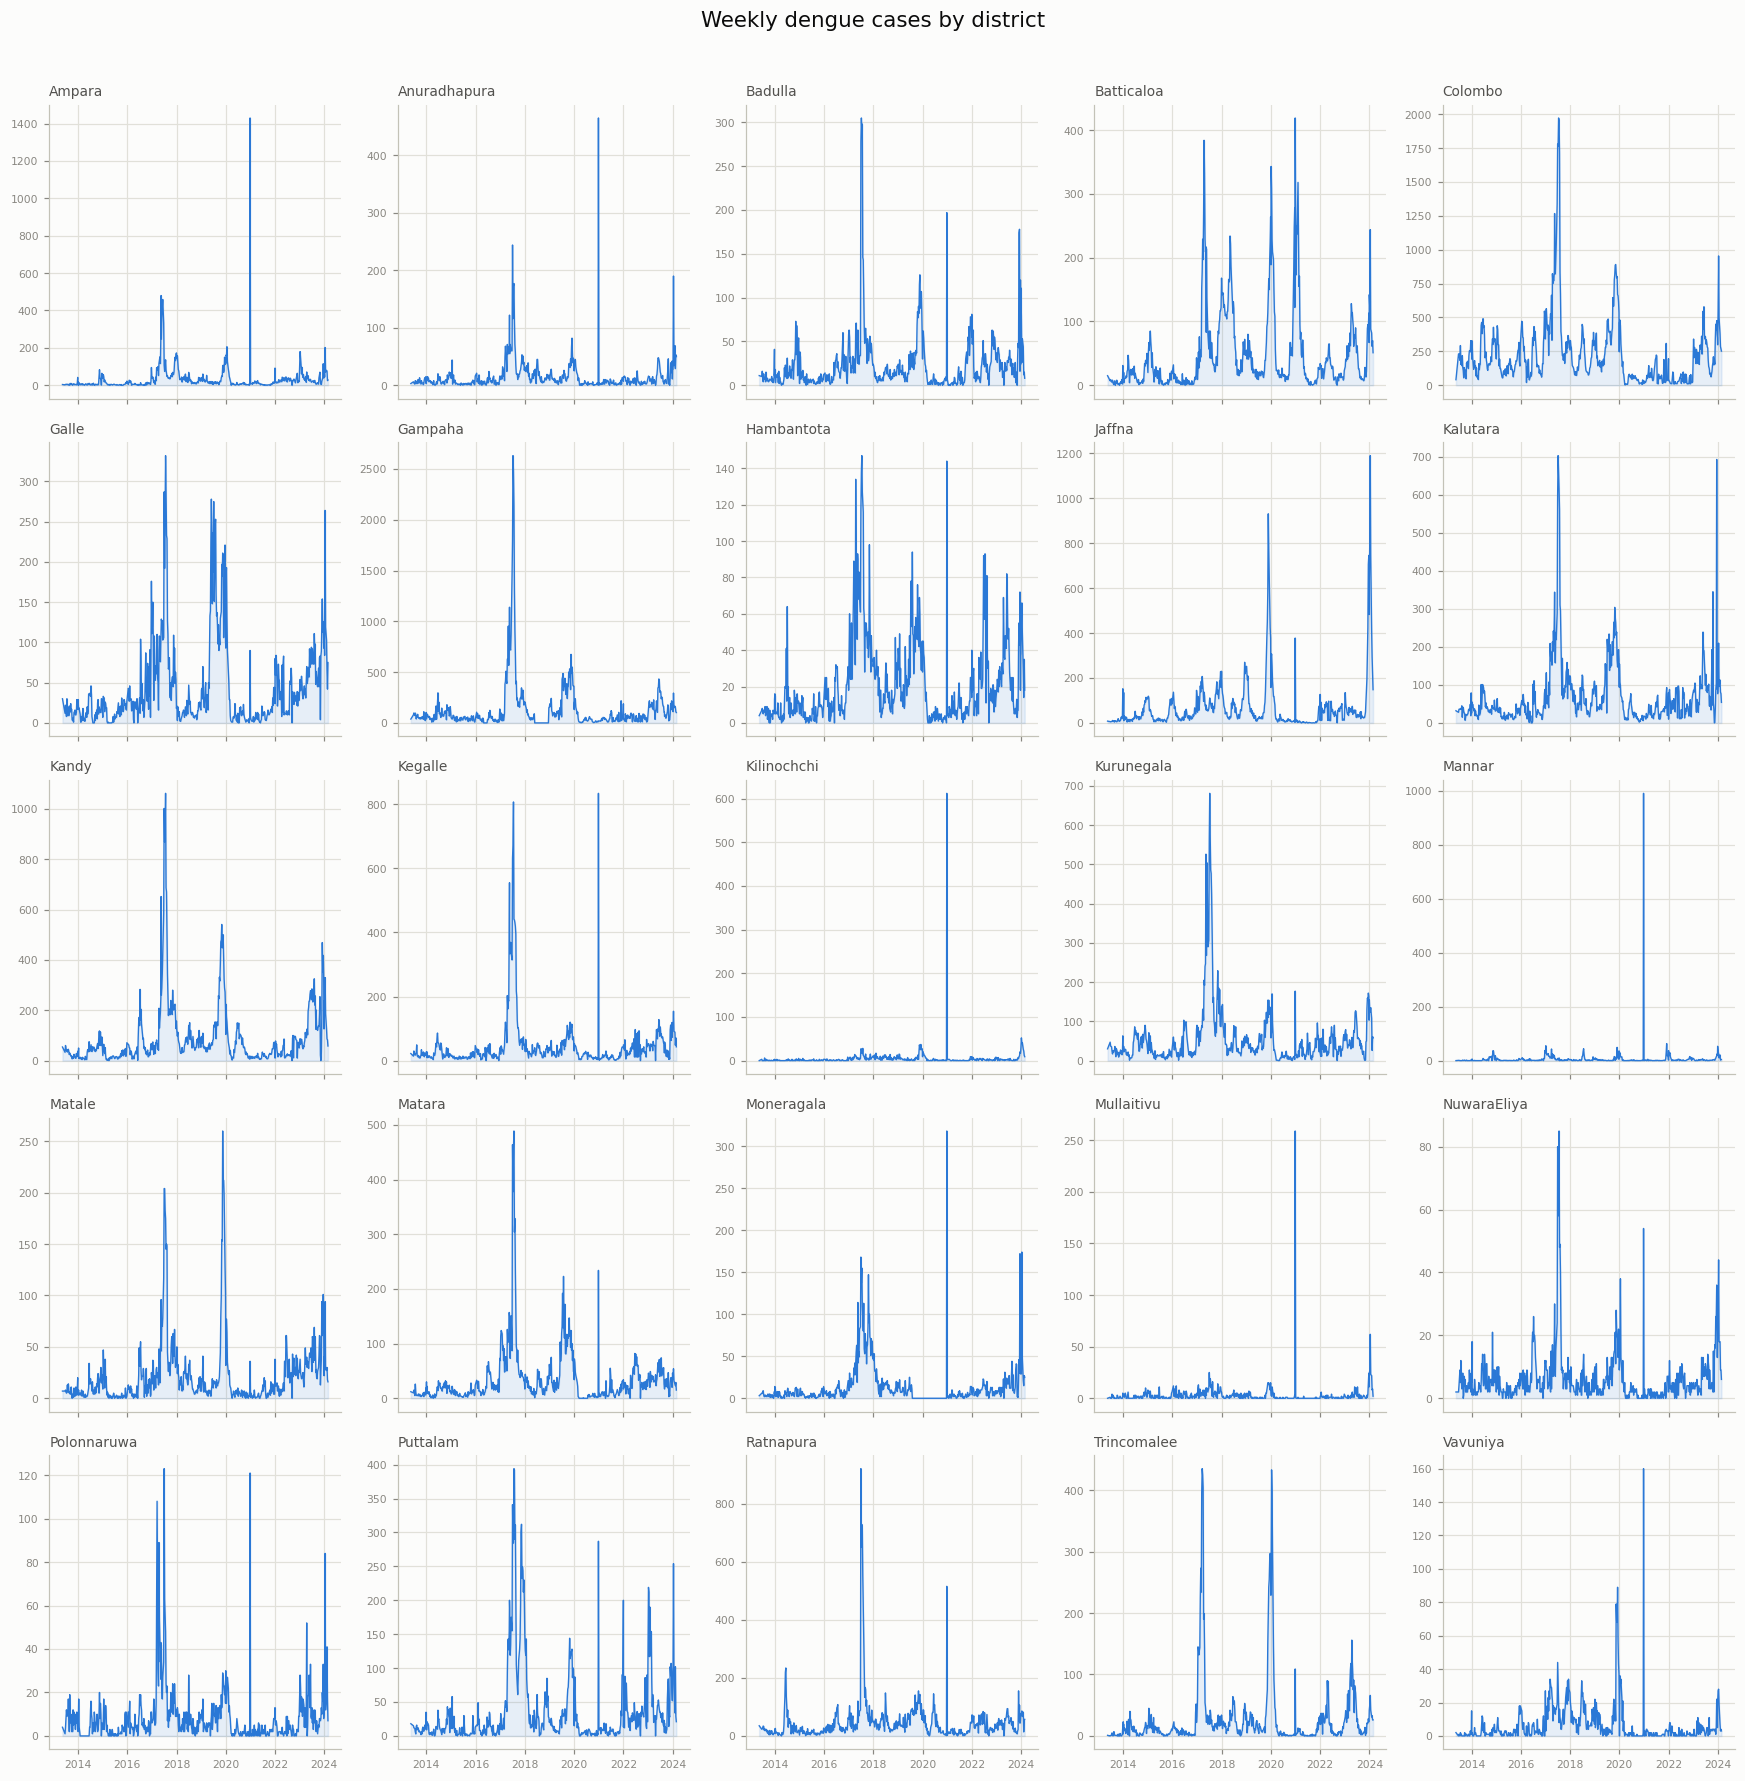

In [16]:
# Small multiples across districts (identity carried by facet position + title, not by
# dozens of distinct hues — a single restrained hue reads far better at this count).
n = len(districts)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows), sharex=True)
axes_flat = np.array(axes).reshape(-1)
for ax, d in zip(axes_flat, districts):
    sub = df[df["region"] == d].sort_values("Week")
    ax.plot(sub["Week"], sub["cases"], color=COLORS["blue"], linewidth=0.9)
    ax.fill_between(sub["Week"], sub["cases"], color=COLORS["blue"], alpha=0.10)
    ax.set_title(d, fontsize=9, color=INK_SECONDARY, loc="left")
    ax.tick_params(labelsize=7)
    style_ax(ax)
for ax in axes_flat[n:]:
    ax.axis("off")
fig.suptitle("Weekly dengue cases by district", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

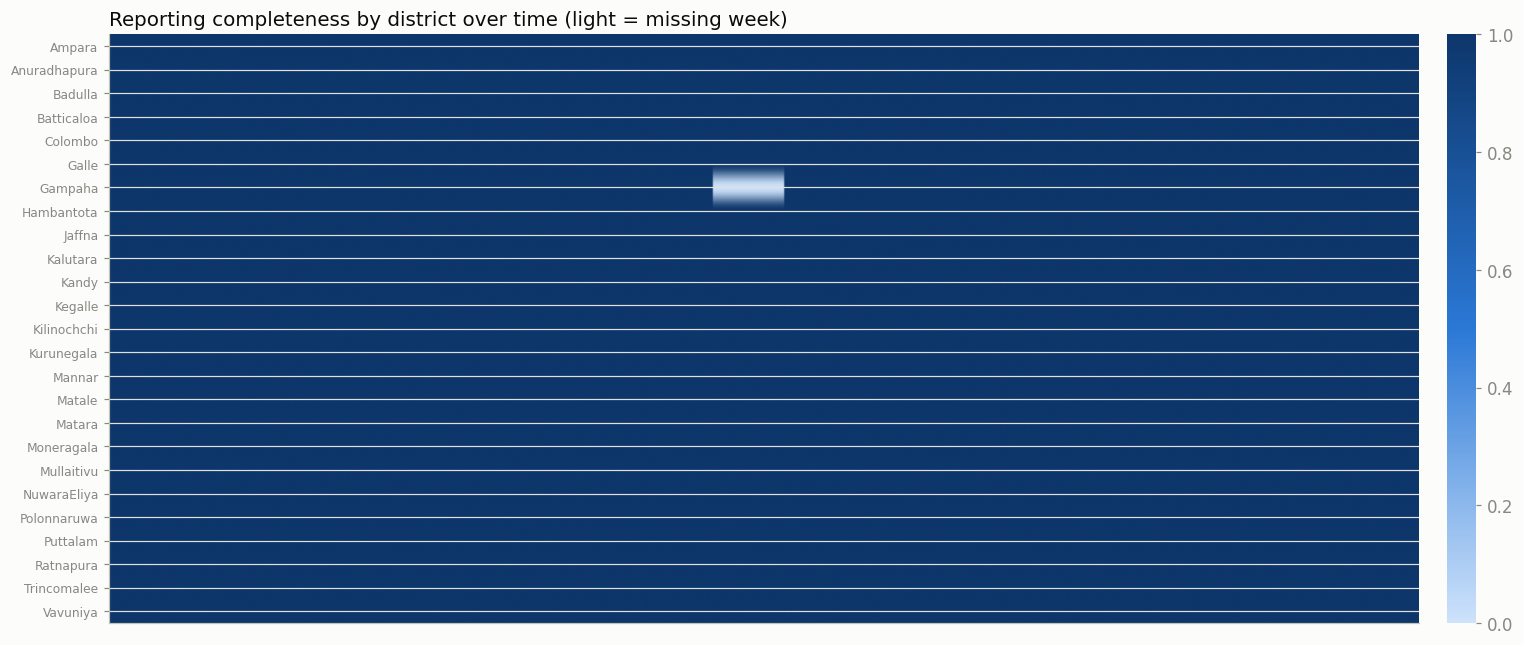

In [17]:
import matplotlib.colors as mcolors

if N_FEATURES is not None and N_FEATURES > 1:
    # Correlation heatmap for one district (paper's Fig. 2 uses Colombo) — correlation
    # is a signed [-1, 1] quantity, so this is a diverging encoding, not a rainbow.
    focus_district = "Colombo" if "Colombo" in districts else districts[0]
    sub = df[df["region"] == focus_district].drop(columns=["Week", "region"])
    sub_numeric = sub.select_dtypes(include=[np.number])
    corr = sub_numeric.corr()

    cmap = mcolors.LinearSegmentedColormap.from_list("diverging", DIVERGING)
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=8)
    ax.set_title(f"Feature correlation matrix — {focus_district}", loc="left", fontsize=13)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    # Disease-only data (N_FEATURES == 1): no covariates to correlate, so instead show
    # data completeness — a sequential (single-hue) encoding of a genuine magnitude
    # (0 = never reported, 1 = always reported), which is the more useful diagnostic
    # for a dataset this raw.
    if "_observed" in long_df.columns:
        completeness = long_df.pivot(index="region", columns="Week", values="_observed").reindex(node_districts)
        fig, ax = plt.subplots(figsize=(14, 6))
        seq_cmap = mcolors.LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"])
        im = ax.imshow(completeness.astype(float), cmap=seq_cmap, aspect="auto", vmin=0, vmax=1)
        ax.set_yticks(range(len(completeness.index))); ax.set_yticklabels(completeness.index, fontsize=8)
        ax.set_xticks([])
        ax.set_title("Reporting completeness by district over time (light = missing week)", loc="left", fontsize=13)
        cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.outline.set_visible(False)
        plt.tight_layout()
        plt.show()
    else:
        print("No per-cell observed/missing tracking available for this dataset — skipping.")

In [18]:
missing_pct = (df.isna().mean() * 100).round(2)
print("Missing value % by column:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False) if (missing_pct > 0).any()
      else "No missing values.")

Missing value % by column:
No missing values.


## 7. Save the manifest for notebooks 01 and 02

In [19]:
manifest = {
    "mode": MODE,
    "csv_path": os.path.abspath(CSV_PATH),
    "npy_path": os.path.abspath(NPY_PATH),
    "adj_path": os.path.abspath(ADJ_PATH),
    "n_districts": len(districts),
    "districts": districts,
    "npy_shape": list(x.shape),
    "n_features": int(N_FEATURES),
    "disease_feature_index": int(disease_col_idx),
    "date_range": [str(df['Week'].min().date()), str(df['Week'].max().date())],
}
manifest_path = "./data_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Wrote {manifest_path}")
print(json.dumps(manifest, indent=2))

if MODE == "raw":
    print(f"\nNOTE: this is a disease-case-only reproduction (no NASA meteorological "
          f"covariates yet) covering {manifest['date_range'][0]} to {manifest['date_range'][1]} "
          f"({len(all_weeks)} weeks). Weng et al. used 2013-2022 with covariates — compare "
          f"the date coverage above against that, and document the missing-covariates gap "
          f"in the proposal regardless of how the date ranges compare. Notebooks 01/02 will "
          f"run in disease-only mode automatically based on n_features == 1 in this manifest.")

Wrote ./data_manifest.json
{
  "mode": "raw",
  "csv_path": "/content/Data/processed/sri_lanka_disease_only.csv",
  "npy_path": "/content/Data/processed/sri_lanka_disease_only.npy",
  "adj_path": "/content/Data/processed/sri_lanka_adj_list.json",
  "n_districts": 25,
  "districts": [
    "Ampara",
    "Anuradhapura",
    "Badulla",
    "Batticaloa",
    "Colombo",
    "Galle",
    "Gampaha",
    "Hambantota",
    "Jaffna",
    "Kalutara",
    "Kandy",
    "Kegalle",
    "Kilinochchi",
    "Kurunegala",
    "Mannar",
    "Matale",
    "Matara",
    "Moneragala",
    "Mullaitivu",
    "NuwaraEliya",
    "Polonnaruwa",
    "Puttalam",
    "Ratnapura",
    "Trincomalee",
    "Vavuniya"
  ],
  "npy_shape": [
    551,
    25,
    1
  ],
  "n_features": 1,
  "disease_feature_index": 0,
  "date_range": [
    "2013-05-15",
    "2024-02-24"
  ]
}

NOTE: this is a disease-case-only reproduction (no NASA meteorological covariates yet) covering 2013-05-15 to 2024-02-24 (551 weeks). Weng et al. used

## Next steps

- **`01_baselines_classical.ipynb`** — ARIMAX/ARIMA, Random Forest, XGBoost, ARNN, LSTM
  (+ naive/seasonal-naive) per district, reproducing Table I of Weng et al. (2024). Reads
  `manifest["n_features"]` to decide whether covariates are available.
- **`02_baselines_gnn.ipynb`** — STGAT, A3TGCN, ASTGCN, DCRNN, AAGCN using the exact
  reference architectures from the paper's GitHub repo, run in disease-only mode if
  `n_features == 1`.

Both notebooks read `data_manifest.json` written above — if you re-run this notebook in
a fresh runtime, re-run it first so the manifest points at valid (mounted) paths.